# High Frequency Data and Limit Order Books

## Lab 4

AMRI Imad, CHIBA Nesrine, JAMAL Adonis

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from tqdm import tqdm

In [36]:
trades = np.array([[pd.read_csv(f"Data/stock{i}_day{j}_trades.csv.gz") for i in range(0, 3)] for j in range(0, 5)], dtype=object)
df_trades = pd.concat([df.assign(stock=i, day=j) for (j, i), df in np.ndenumerate(trades)], ignore_index=True)

In [20]:
full_run = False

if full_run:
    N_PATHS = 300
    tau_values = [1, 5, 10, 30, 60, 120, 300, 600]

    intensities = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
    n_mc = 300
    n_mc_gauss = 1000
    intensities_corr = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]
    n_mc_corr = 300


else:
    N_PATHS = 10
    tau_values = [1, 5, 10, 120, 600]
    
    intensities = [0.1, 10.0, 20.0]
    n_mc = 10
    n_mc_gauss = 10
    intensities_corr = [0.1, 10.0, 20.0]
    n_mc_corr = 10

1. **Brownian motions with Poisson sampling:** Take your results from Lab 2 Question 2 and add the Hayashi-Yoshida estimator to the plot. Comment.

We now implement the Hayashi-Yoshida estimator. Consiering two processes ($k=1,2$): $$dP_k (t) = \mu_k (t)dt + \sigma_k (t)dW_k (t)$$ with $(W_k(t))_t$ Brownian motions and $d\langle W_1, W_2 \rangle_t = \rho(t) dt$ for some deterministic functions $\rho, \sigma_1$ and $\sigma_2$.

The Hayashi-Yoshida covariance estimator is $$U_n = \sum_{i,j} \Delta P_1(I^i) \Delta P_2(J^j) \mathbf{1}_{\{I^i \cap J^j \neq \emptyset\}}$$

In [31]:
# Lab 2 Question 2
def simulate_poisson_sampled_bm(T, sigma1, sigma2, rho, mu1, mu2, n_paths=200, seed=0):
    rng    = np.random.default_rng(seed)
    paths  = []
    dt_fine = 1e-3         
    n_fine  = int(T / dt_fine)
    t_fine  = np.linspace(0, T, n_fine + 1)

    for _ in range(n_paths):
        # Correlated BM increments
        Z1 = rng.standard_normal(n_fine)
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * rng.standard_normal(n_fine)
        dW1 = sigma1 * np.sqrt(dt_fine) * Z1
        dW2 = sigma2 * np.sqrt(dt_fine) * Z2
        p1  = np.concatenate([[0], np.cumsum(dW1)])
        p2  = np.concatenate([[0], np.cumsum(dW2)])

        # Independent Poisson observation times
        obs1 = np.sort(rng.uniform(0, T, rng.poisson(mu1 * T)))
        obs2 = np.sort(rng.uniform(0, T, rng.poisson(mu2 * T)))

        # Interpolate BM at observation times
        p1_obs = np.interp(obs1, t_fine, p1)
        p2_obs = np.interp(obs2, t_fine, p2)
        paths.append((obs1, p1_obs, obs2, p2_obs))

    return paths


def realized_covariance(times1, prices1, times2, prices2, tau, T):
    """
    Previous-tick synchronization on a regular grid with spacing tau,
    then compute realized covariance.
    """
    grid = np.arange(0, T + tau, tau)
    # Previous-tick interpolation
    def prev_tick(obs_t, obs_p, grid):
        idx = np.searchsorted(obs_t, grid, side='right') - 1
        idx = np.clip(idx, 0, len(obs_p) - 1)
        return obs_p[idx]

    p1_g = prev_tick(times1, prices1, grid)
    p2_g = prev_tick(times2, prices2, grid)
    r1 = np.diff(p1_g)
    r2 = np.diff(p2_g)
    return np.sum(r1 * r2)


# Hayashi yoshida estimator
def hayashi_yoshida(times1, prices1, times2, prices2):
    dp1 = np.diff(prices1)
    dp2 = np.diff(prices2)
    n1, n2 = len(dp1), len(dp2)
    
    hy = 0.0
    j_start = 0
    for i in range(n1):
        a_i, b_i = times1[i], times1[i + 1]
        for j in range(j_start, n2):
            a_j, b_j = times2[j], times2[j + 1]
            if a_j >= b_i:
                break
            if b_j <= a_i:
                j_start = j + 1
                continue
            hy += dp1[i] * dp2[j]
    return hy


def hayashi_yoshida_correlation(times1, prices1, times2, prices2):
    hy_cov = hayashi_yoshida(times1, prices1, times2, prices2)
    rv1 = np.sum(np.diff(prices1) ** 2)
    rv2 = np.sum(np.diff(prices2) ** 2)
    return hy_cov / np.sqrt(rv1 * rv2)


In [22]:
# Parameters 
T_BM   = 3600.0 # 1 hour simulation
sigma1 = 0.01
sigma2 = 0.01
rho    = 0.7
mu1    = 1.0      
mu2    = 1.0
true_cov = rho * sigma1 * sigma2 * T_BM
print(f"True covariance [p1,p2]_T = rho*sigma1*sigma2*T = {true_cov:.4f}")

paths = simulate_poisson_sampled_bm(T_BM, sigma1, sigma2, rho, mu1, mu2, n_paths=N_PATHS, seed=42)

True covariance [p1,p2]_T = rho*sigma1*sigma2*T = 0.2520


In [23]:
rcov_means = []
rcov_stds  = []
for tau in tau_values:
    rcovs = [realized_covariance(*p, tau, T_BM) for p in paths]
    rcov_means.append(np.mean(rcovs))
    rcov_stds.append(np.std(rcovs))

In [24]:
hy_covs = [hayashi_yoshida(*p) for p in paths]
hy_mean = np.mean(hy_covs)
hy_std = np.std(hy_covs)

hy_corrs = [hayashi_yoshida_correlation(*p) for p in paths]
hy_corr_mean = np.mean(hy_corrs)
hy_corr_std = np.std(hy_corrs)

print(f"Hayashi-Yoshida covariance:  mean = {hy_mean:.6f},  std = {hy_std:.6f}")
print(f"True covariance:             {true_cov:.6f}")
print(f"Bias:                        {hy_mean - true_cov:.6f}")
print()
print(f"HY correlation estimator:    mean = {hy_corr_mean:.4f},  std = {hy_corr_std:.4f}")
print(f"True rho:                    {rho:.4f}")

Hayashi-Yoshida covariance:  mean = 0.246840,  std = 0.011225
True covariance:             0.252000
Bias:                        -0.005160

HY correlation estimator:    mean = 0.6904,  std = 0.0247
True rho:                    0.7000


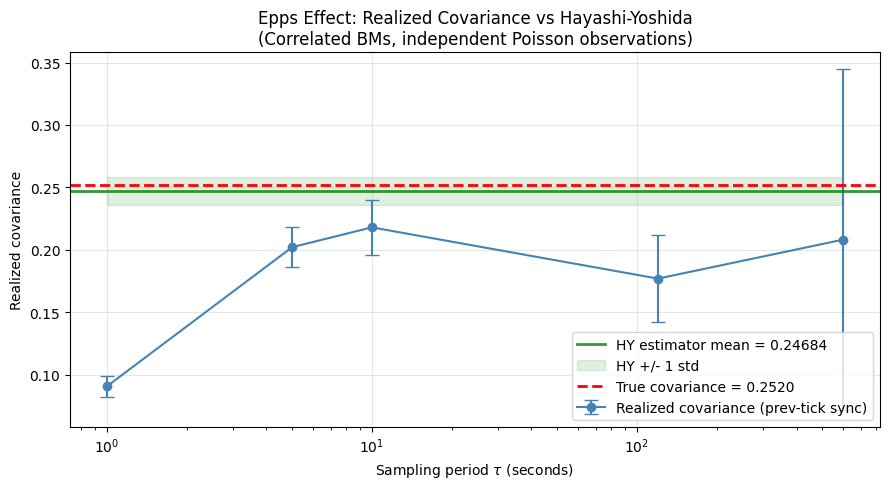


   tau (s) |      RC mean |     RC std |    RC bias
-------------------------------------------------------
         1 |      0.09074 |    0.00826 |   -0.16126
         5 |      0.20216 |    0.01598 |   -0.04984
        10 |      0.21805 |    0.02194 |   -0.03395
       120 |      0.17701 |    0.03467 |   -0.07499
       600 |      0.20822 |    0.13647 |   -0.04378

        HY |      0.24684 |    0.01122 |   -0.00516


In [25]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.errorbar(tau_values, rcov_means, yerr=rcov_stds, fmt='o-',
            color='steelblue', capsize=5, label='Realized covariance (prev-tick sync)')

ax.axhline(hy_mean, color='green', linestyle='-', lw=2, alpha=0.8,
           label=f'HY estimator mean = {hy_mean:.5f}')
ax.fill_between(tau_values, hy_mean - hy_std, hy_mean + hy_std,
                color='green', alpha=0.12, label='HY +/- 1 std')

ax.axhline(true_cov, color='red', linestyle='--', lw=2,
           label=f'True covariance = {true_cov:.4f}')

ax.set_xscale('log')
ax.set_xlabel(r'Sampling period $\tau$ (seconds)')
ax.set_ylabel('Realized covariance')
ax.set_title('Epps Effect: Realized Covariance vs Hayashi-Yoshida\n'
             '(Correlated BMs, independent Poisson observations)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'tau (s)':>10} | {'RC mean':>12} | {'RC std':>10} | {'RC bias':>10}")
print('-' * 55)
for tau, m, s in zip(tau_values, rcov_means, rcov_stds):
    print(f"{tau:>10} | {m:>12.5f} | {s:>10.5f} | {m - true_cov:>10.5f}")
print(f"\n{'HY':>10} | {hy_mean:>12.5f} | {hy_std:>10.5f} | {hy_mean - true_cov:>10.5f}")

We also show numerically that the estimator is consistent: $$ U_n \xrightarrow[n \xrightarrow{} +\infty]{\mathbb{P}} \int_0^T \sigma_1 (t) \sigma_2 (t) \rho (t) dt $$

Intensities: 100%|██████████| 3/3 [00:10<00:00,  3.39s/it]


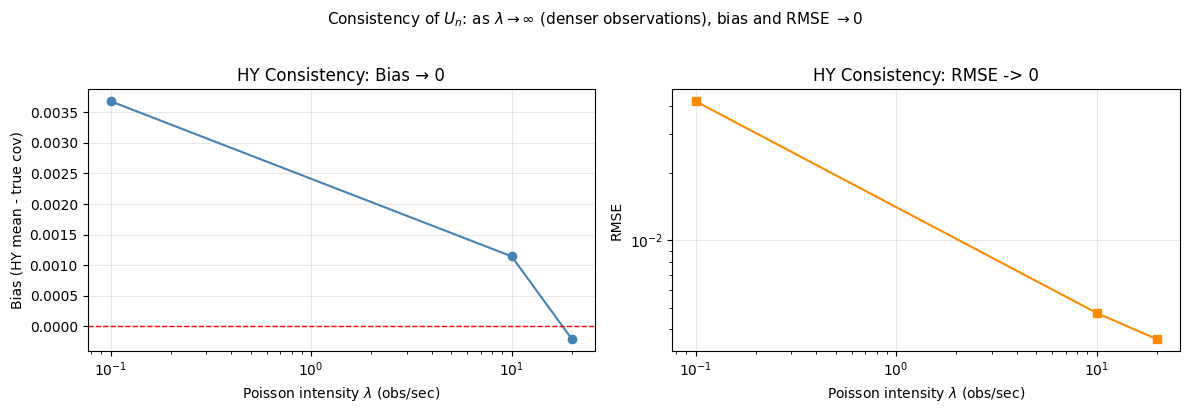

    lambda |         Bias |         RMSE
----------------------------------------
       0.1 |     0.003684 |     0.041990
      10.0 |     0.001143 |     0.004730
      20.0 |    -0.000215 |     0.003606


In [26]:
rng_seed = 123

hy_bias = []
hy_rmse = []

for lam in tqdm(intensities, desc="Intensities"):
    sims = simulate_poisson_sampled_bm(T_BM, sigma1, sigma2, rho, lam, lam, n_paths=n_mc, seed=rng_seed)
    covs = np.array([hayashi_yoshida(*p) for p in sims])
    hy_bias.append(np.mean(covs) - true_cov)
    hy_rmse.append(np.sqrt(np.mean((covs - true_cov)**2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(intensities, hy_bias, 'o-', color='steelblue')
ax1.axhline(0, color='red', ls='--', lw=1)
ax1.set_xlabel(r'Poisson intensity $\lambda$ (obs/sec)')
ax1.set_ylabel('Bias (HY mean - true cov)')
ax1.set_title('HY Consistency: Bias → 0')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)

ax2.plot(intensities, hy_rmse, 's-', color='darkorange')
ax2.set_xlabel(r'Poisson intensity $\lambda$ (obs/sec)')
ax2.set_ylabel('RMSE')
ax2.set_title('HY Consistency: RMSE -> 0')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.suptitle(r'Consistency of $U_n$: as $\lambda \to \infty$ (denser observations), bias and RMSE $\to 0$',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'lambda':>10} | {'Bias':>12} | {'RMSE':>12}")
print('-' * 40)
for lam, b, r in zip(intensities, hy_bias, hy_rmse):
    print(f"{lam:>10.1f} | {b:>12.6f} | {r:>12.6f}")

We show numerically that the estimator is asymptatically gaussian.

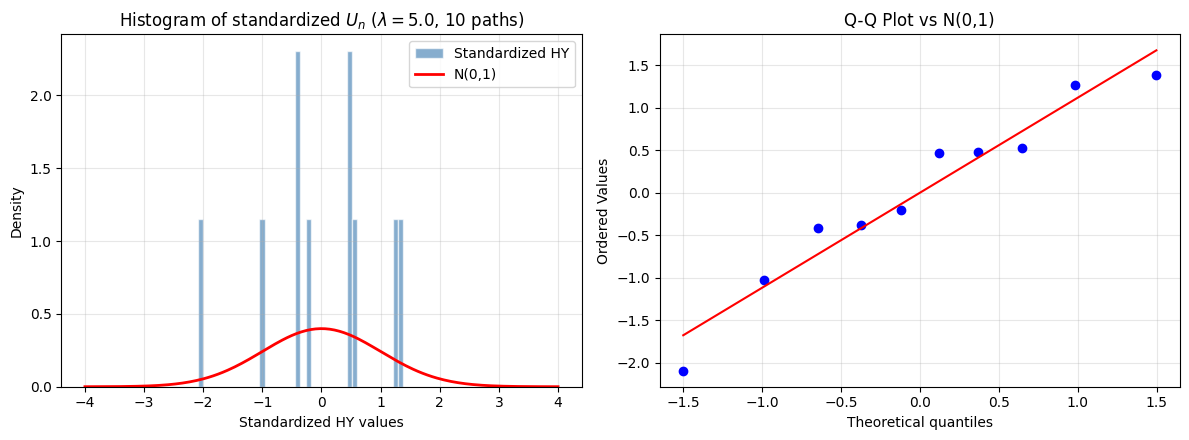

Shapiro-Wilk test:  statistic = 0.9470,  p-value = 0.6327
Jarque-Bera test:   statistic = 0.5279,  p-value = 0.7680

Skewness:  -0.5371
Kurtosis:  -0.3366  (excess, should be approx 0 for Gaussian)


In [27]:
lam_test = 5.0
sims_gauss = simulate_poisson_sampled_bm(T_BM, sigma1, sigma2, rho, lam_test, lam_test, n_paths=n_mc_gauss, seed=456)
hy_vals = np.array([hayashi_yoshida(*p) for p in sims_gauss])

hy_centered = hy_vals - np.mean(hy_vals)
hy_standardized = hy_centered / np.std(hy_vals)

# tests
shapiro_stat, shapiro_p = stats.shapiro(hy_standardized)
jb_stat, jb_p = stats.jarque_bera(hy_standardized)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.hist(hy_standardized, bins=40, density=True, alpha=0.65, color='steelblue',
         edgecolor='white', label='Standardized HY')
x_grid = np.linspace(-4, 4, 200)
ax1.plot(x_grid, stats.norm.pdf(x_grid), 'r-', lw=2, label='N(0,1)')
ax1.set_xlabel('Standardized HY values')
ax1.set_ylabel('Density')
ax1.set_title(f'Histogram of standardized $U_n$ ($\\lambda={lam_test}$, {n_mc_gauss} paths)')
ax1.legend()
ax1.grid(True, alpha=0.3)

stats.probplot(hy_standardized, dist='norm', plot=ax2)
ax2.set_title('Q-Q Plot vs N(0,1)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Shapiro-Wilk test:  statistic = {shapiro_stat:.4f},  p-value = {shapiro_p:.4f}")
print(f"Jarque-Bera test:   statistic = {jb_stat:.4f},  p-value = {jb_p:.4f}")
print(f"\nSkewness:  {stats.skew(hy_standardized):.4f}")
print(f"Kurtosis:  {stats.kurtosis(hy_standardized):.4f}  (excess, should be approx 0 for Gaussian)")

Finally we check the following property: In the case of constant $\rho$, $\sigma_1$ and $\sigma_2$, the correlation estimator is also consistent: $$ \frac{\sum_{i,j} \Delta P_1(I^i)\Delta P_2(J^j)\mathbf{1}_{I^i \cap J^j \neq \emptyset}}{\sqrt{\sum_i \Delta P_1(I^i)^2}\sqrt{\sum_j \Delta P_2(J^j)^2}} \to \rho \text{ in probability when } n \to +\infty. $$

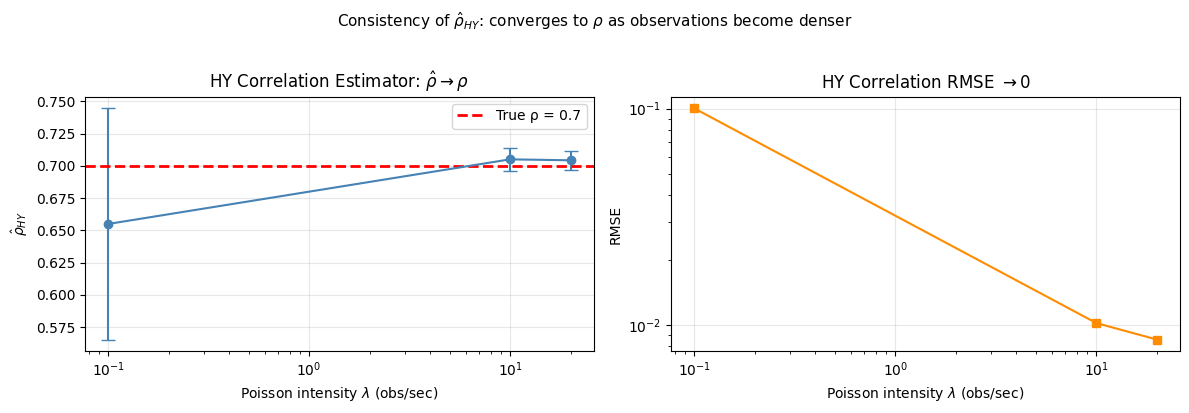

    lambda |  Mean rho_HY |        Std |       RMSE
--------------------------------------------------
       0.1 |       0.6549 |     0.0896 |     0.1003
      10.0 |       0.7050 |     0.0089 |     0.0102
      20.0 |       0.7043 |     0.0074 |     0.0086

True rho = 0.7


In [28]:
corr_means = []
corr_stds  = []
corr_rmse  = []

for lam in intensities_corr:
    sims = simulate_poisson_sampled_bm(T_BM, sigma1, sigma2, rho, lam, lam,
                                       n_paths=n_mc_corr, seed=789)
    corrs = np.array([hayashi_yoshida_correlation(*p) for p in sims])
    corr_means.append(np.mean(corrs))
    corr_stds.append(np.std(corrs))
    corr_rmse.append(np.sqrt(np.mean((corrs - rho)**2)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.errorbar(intensities_corr, corr_means, yerr=corr_stds, fmt='o-',
             color='steelblue', capsize=5)
ax1.axhline(rho, color='red', ls='--', lw=2, label=f'True ρ = {rho}')
ax1.set_xlabel(r'Poisson intensity $\lambda$ (obs/sec)')
ax1.set_ylabel(r'$\hat{\rho}_{HY}$')
ax1.set_title(r'HY Correlation Estimator: $\hat{\rho} \to \rho$')
ax1.set_xscale('log')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(intensities_corr, corr_rmse, 's-', color='darkorange')
ax2.set_xlabel(r'Poisson intensity $\lambda$ (obs/sec)')
ax2.set_ylabel('RMSE')
ax2.set_title(r'HY Correlation RMSE $\to 0$')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.suptitle(r'Consistency of $\hat{\rho}_{HY}$: converges to $\rho$ as observations become denser',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print(f"{'lambda':>10} | {'Mean rho_HY':>12} | {'Std':>10} | {'RMSE':>10}")
print('-' * 50)
for lam, m, s, r in zip(intensities_corr, corr_means, corr_stds, corr_rmse):
    print(f"{lam:>10.1f} | {m:>12.4f} | {s:>10.4f} | {r:>10.4f}")
print(f"\nTrue rho = {rho}")

**Interpretation and analysis**

The resulting plot clearly shows the advantage of the Hayashi-Yoshida estimator:

- Epps effect in realized covariance

- Unbiased HY estimator

Moreover, as expected from the theory, we show that the Hayashi-Yoshida estimator is:
- Consistent.
- Asymptotically Gaussian, both tests fail to reject normality at the 5% level.
- The correlation estimator is consistent.

2. **Signature plots and Epps effect:** On your dataset, estimate the integrated realized variances for each stock and the correlation between each pair of stocks using the standard estimators and the Hayashi-Yoshida estimators. Comment.

In [38]:
df_trades['ts_dt'] = pd.to_datetime(df_trades['ts'])
midnight = df_trades['ts_dt'].dt.normalize()
df_trades['t_sec'] = (df_trades['ts_dt'] - midnight).dt.total_seconds()
df_trades['log_price'] = np.log(df_trades['price'])

def get_stock_day(stock_id, day_id):
    sub = (df_trades[(df_trades['stock'] == stock_id) & (df_trades['day'] == day_id)]
           .sort_values('t_sec'))
    return sub['t_sec'].values, sub['log_price'].values

n_stocks, n_days = 3, 5
pairs = [(0, 1), (0, 2), (1, 2)]

In [39]:
def rv_prev_tick(times, lp, tau):
    grid = np.arange(times[0], times[-1] + tau, tau)
    idx  = np.clip(np.searchsorted(times, grid, side='right') - 1, 0, len(lp) - 1)
    return np.sum(np.diff(lp[idx]) ** 2)

def hy_variance(lp):
    return np.sum(np.diff(lp) ** 2)

tau_sig = [1, 2, 5, 10, 30, 60, 120, 300, 600]

rv_sig = np.array([
    [np.mean([rv_prev_tick(*get_stock_day(s, d), tau) for d in range(n_days)])
     for tau in tau_sig]
    for s in range(n_stocks)
])

hy_var = np.array([
    np.mean([hy_variance(get_stock_day(s, d)[1]) for d in range(n_days)])
    for s in range(n_stocks)
])

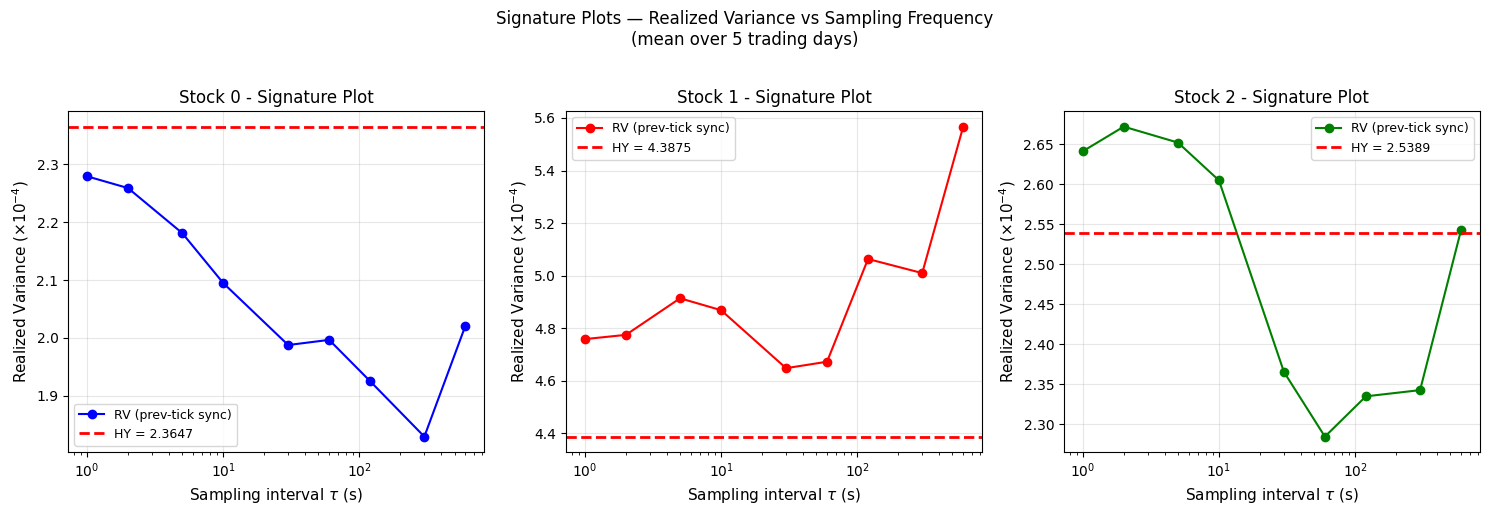

In [40]:
stock_colors = ['blue', 'red', 'green']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for s, (ax, col) in enumerate(zip(axes, stock_colors)):
    ax.plot(tau_sig, rv_sig[s] * 1e4, 'o-', color=col, label='RV (prev-tick sync)')
    ax.axhline(hy_var[s] * 1e4, color='red', ls='--', lw=2,
               label=f'HY = {hy_var[s]*1e4:.4f}')
    ax.set_xscale('log')
    ax.set_xlabel(r'Sampling interval $\tau$ (s)', fontsize=11)
    ax.set_ylabel(r'Realized Variance ($\times 10^{-4}$)', fontsize=11)
    ax.set_title(f'Stock {s} - Signature Plot')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
plt.suptitle('Signature Plots — Realized Variance vs Sampling Frequency\n(mean over 5 trading days)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [41]:
def rc_pair(s1, s2, tau, day):
    t1, lp1 = get_stock_day(s1, day)
    t2, lp2 = get_stock_day(s2, day)
    t0    = max(t1[0], t2[0])
    t_end = min(t1[-1], t2[-1])
    grid  = np.arange(t0, t_end + tau, tau)
    def ptick(times, lp, g):
        return lp[np.clip(np.searchsorted(times, g, side='right') - 1, 0, len(lp) - 1)]
    r1 = np.diff(ptick(t1, lp1, grid))
    r2 = np.diff(ptick(t2, lp2, grid))
    v1, v2 = np.sum(r1 ** 2), np.sum(r2 ** 2)
    return np.sum(r1 * r2) / np.sqrt(v1 * v2) if v1 > 0 and v2 > 0 else np.nan

rc_sig = np.array([
    [np.nanmean([rc_pair(s1, s2, tau, d) for d in range(n_days)])
     for tau in tau_sig]
    for s1, s2 in pairs
])

hy_corr_pairs = np.array([
    np.mean([hayashi_yoshida_correlation(*get_stock_day(s1, d), *get_stock_day(s2, d))
             for d in range(n_days)])
    for s1, s2 in pairs
])

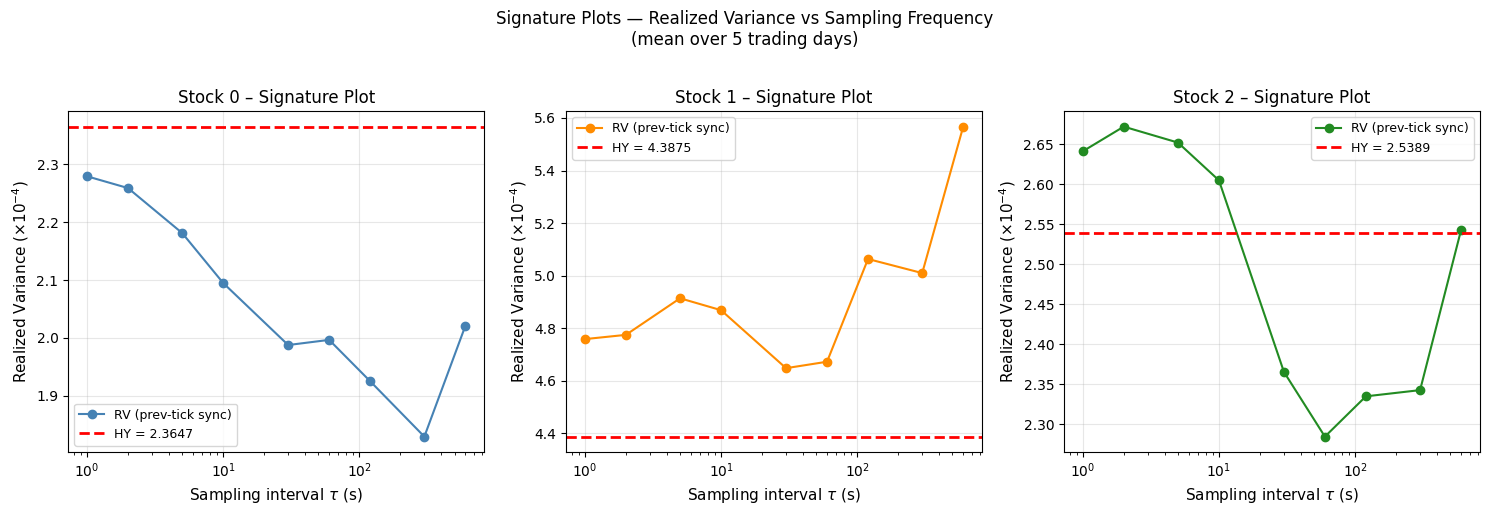

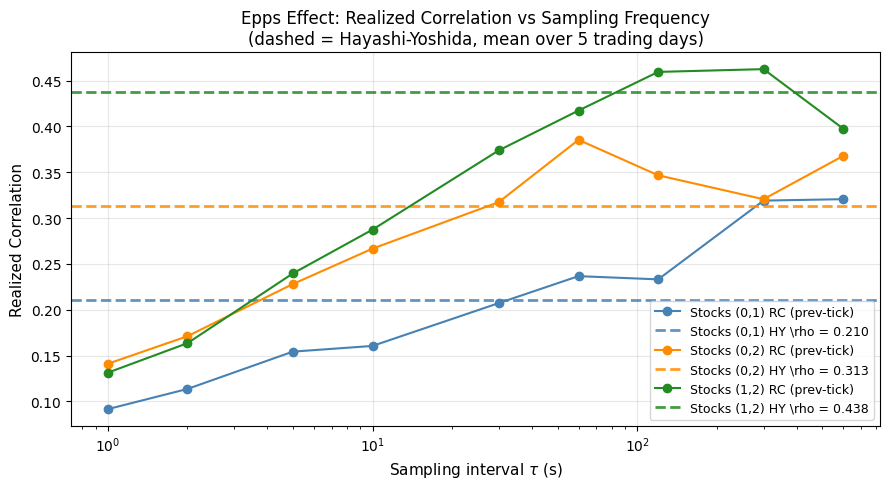

=== Realized Variance (\tau=60s vs HY variance) ===
Stock    | RV (\tau=60s) x1e4 |    HY Var x1e4 |    HY/RV
----------------------------------------------------------
Stock 0   |            1.9967 |         2.3647 |    1.184
Stock 1   |            4.6725 |         4.3875 |    0.939
Stock 2   |            2.2846 |         2.5389 |    1.111

=== Pairwise Correlations (\tau=60s vs HY) ===
Pair       | RC (\tau=60s) |    HY \rho
--------------------------------------
(0,1)       |       0.2366 |     0.2102
(0,2)       |       0.3853 |     0.3133
(1,2)       |       0.4173 |     0.4376


In [ ]:
pair_labels = [f'Stocks ({s1},{s2})' for s1, s2 in pairs]
fig, ax = plt.subplots(figsize=(9, 5))
for idx, (label, col) in enumerate(zip(pair_labels, stock_colors)):
    ax.plot(tau_sig, rc_sig[idx], 'o-', color=col, label=f'{label} RC (prev-tick)')
    ax.axhline(hy_corr_pairs[idx], color=col, ls='--', lw=2, alpha=0.85,
               label=f'{label} HY \\rho = {hy_corr_pairs[idx]:.3f}')

ax.set_xscale('log')
ax.set_xlabel(r'Sampling interval $\tau$ (s)', fontsize=11)
ax.set_ylabel('Realized Correlation', fontsize=11)
ax.set_title('Epps Effect: Realized Correlation vs Sampling Frequency\n'
             '(dashed = Hayashi-Yoshida, mean over 5 trading days)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

tau_ref_idx = tau_sig.index(60)
print("=== Realized Variance (\\tau=60s vs HY variance) ===")
print(f"{'Stock':<8} | {'RV (\\tau=60s) x1e4':>17} | {'HY Var x1e4':>14} | {'HY/RV':>8}")
print('-' * 58)
for s in range(n_stocks):
    ratio = hy_var[s] / rv_sig[s, tau_ref_idx]
    print(f"Stock {s:<3} | {rv_sig[s, tau_ref_idx]*1e4:>17.4f} | {hy_var[s]*1e4:>14.4f} | {ratio:>8.3f}")

print(f"\n=== Pairwise Correlations (\\tau=60s vs HY) ===")
print(f"{'Pair':<10} | {'RC (\\tau=60s)':>12} | {'HY \\rho':>10}")
print('-' * 38)
for idx, (s1, s2) in enumerate(pairs):
    print(f"({s1},{s2}){'':<6} | {rc_sig[idx, tau_ref_idx]:>12.4f} | {hy_corr_pairs[idx]:>10.4f}")


**Interpretation**

**Signature plots (realized variance vs τ):**
- At high sampling frequencies (small τ), the realized variance is strongly inflated above the HY benchmark. This is the **microstructure noise bias**: bid-ask bounce and rounding effects inject spurious variance into tick-by-tick returns, which disappears as τ increases and the noise averages out.
- For large τ (several minutes), RV converges toward the HY estimate from below: at very coarse sampling we lose statistical efficiency (few observations per day). The HY estimator — which uses every tick without synchronization — sits at the efficient, noise-sensitive level and serves as the tick-by-tick limit.
- The "plateau" visible in the mid-frequency range (roughly 30–120 s) identifies the best trade-off frequency for each stock.

**Epps effect (realized correlation vs τ):**
- The realized correlation rises monotonically as τ increases. At very high frequencies (small τ), the synchronization problem is severe: under previous-tick resampling, the two stocks are almost never observed at the same instant, so their returns appear uncorrelated. This **Epps effect** causes a strong downward bias in RC at fine time scales.
- As τ grows the two synchronised grids capture longer movements that genuinely overlap, and the correlation converges toward its true value.
- The **Hayashi-Yoshida estimator** bypasses synchronization entirely by summing products of overlapping intervals. Its value (dashed horizontal line) is close to the large-τ plateau of the realized correlation, confirming it is unbiased and provides the correct long-run estimate without requiring any grid choice.

3. **Lead-lag estimation:** On your dataset, for each pair of stock, estimate the lead-lag
relationship using the Hayashi-Yoshida estimators. Comment.

4. **Hawkes process for trades:** Is a Hawkes process a good model for the time dynamics
of the trades in your dataset ? Explain your experiments in details and use statistical
arguments to support your answers.

5. **Hawkes fit on signature plots:** Fit the single stock Hawkes model of [1] on the
signature plot for each stock of your dataset. Comment.